In [ ]:
# HIDE_INIT
from IPython.display import Javascript
Javascript("""
setTimeout(function() {
    document.querySelectorAll('.jp-CodeCell').forEach(cell => {
        if (cell.innerText.includes("# FEEDBACK CELL") ||
            cell.innerText.includes("# SCORE CELL")) {

            const btn = cell.querySelector('[title="Collapse Input"]');
            if (btn) {
                btn.click();
            }
        }
    });
}, 800);
""")



# Fundamentals


Fundamental to electrical power systems, is to define the time aspect. 

We start with the generic sinusoidal function and recall Euler’s formula:

$$
e^{j\theta} = \cos\theta + j\sin\theta
$$

In this book, we use MKS units and IEEE standards as far as possible.

## The MKS System

The meter–kilogram–second (MKS) system is a system of units where the fundamental units are:

- Length: meter (m)  
- Mass: kilogram (kg)  
- Time: second (s)  

MKS means that all physical quantities are constructed from meter, kilogram, and second, and this forms the basis of the SI units used in power systems.

For example:

$$
1 \, V = \frac{kg \cdot m^2}{s^3 \cdot A}
$$

All physical quantities in power systems are expressed in SI units (MKS-based):

- Voltage: Volt  
- Current: Ampere  
- Power: Watt  
- Impedance: Ohm  

## Per-Unit System

The per-unit system normalizes MKS values by dividing by a chosen base value, producing dimensionless quantities:

$$
x_{pu} = \frac{x_{MKS}}{x_{base}}
$$

### Base Quantities

From the base values $S_{base}$ (VA) and $V_{base}$ (Volt), we can derive:

$$
I_{base} = \frac{S_{base}}{\sqrt{3} V_{base}}
$$

$$
Z_{base} = \frac{V_{base}^2}{S_{base}}
$$

## Time Domain and Phasors

The time-domain representation of voltage can be expressed as:

$$
v(t) = \hat{V} \cdot \cos(\omega t)
$$

Lowercase letters (e.g., $v$) are used to represent instantaneous values that vary as a function of time ($t$), while uppercase letters ($V$) represent constant quantities.

The representation of time-varying and constant quantities is not standardized in the same way as MKS, SI, and IEEE. Instead, it is based on conventions—agreements developed over time about how to express these quantities. This is also a good illustration of the difference between standards and conventions.

Here:

- $\hat{V}$ is the voltage amplitude  
- $f$ is the frequency (typically 50 Hz, i.e., 50 cycles per second)  

In the Python script below, `V_ampl` represents the constant amplitude, while $v(t)$ varies as a function of time.


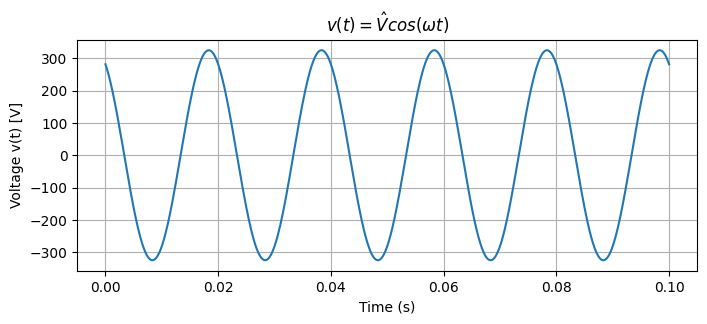

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
V_ampl = 325            # Peak voltage [V]
f = 50                 # Frequency [Hz]
omega = 2*np.pi*f      # Angular frequency
theta_v = np.pi/6     # Phase angle (30 degrees)

# Time vector
t = np.linspace(0, 0.1, 1000)

# Voltage signal
v = V_ampl * np.cos(omega * t + theta_v)

# Plot
plt.figure(figsize=(8, 3))
plt.plot(t, v)
plt.xlabel("Time (s)")
plt.ylabel("Voltage v(t) [V]")
plt.title(r"$v(t) = \hat{V} cos(ωt)$")
plt.grid()
plt.show()

In power systems, it is common to describe $\cos(\omega t)$, because this represents the projection of the voltage $v$ onto the cosine axis and gives the value 1 when $v(t) = 0$. At that point, $v(0)$ equals the constant $V$, which is the same as the amplitude $\hat{V}$.

In this way, the cosine representation describes the system under continuous operation from a steady-state perspective. The steady-state perspective is also important when the vector ($V$) rotates in the time domain and becomes a phasor representation.

## Time Domain (Waveform) and Rotating Vector (Phasor)

The phasor representation becomes particularly useful when analyzing phase shifts, for example in three-phase systems or current phase shifts caused by passive components:

$$
v(t) = \hat{V} \cdot \sin(\omega t) \Longleftrightarrow \bar{V} = \hat{V} \angle \theta
$$

![Phasor animation](phasor_animation_sin.gif)

We use the notation $\bar{V}$ to indicate that this is a complex number with a magnitude (amplitude $\hat{V}$) and a phase ($\theta$). The magnitude is also called the absolute value $|V|$, while the phase is the argument of the complex number.

In power systems, the convention is to use the cosine representation due to the steady-state perspective discussed above.

![Phasor animation](phasor_animation_fixed.gif)

$$
\Re\{e^{j\omega t}\} = \cos(\omega t)
$$

- no additional phase  
- the phasor points along the x-axis at $t = 0$

$$
\Im\{e^{j\omega t}\} = \sin(\omega t)
$$

However, in this case:

- at $t = 0$: value = 0  
- you do not "see" the vector directly  

When using the real part:

$$
v(t) = \Re\{V e^{j\omega t}\}
$$

the relationship becomes:

$$
V = |V| e^{j\theta}
$$

completely direct.

### Result:

$$
v(t) = |V| \cos(\omega t + \theta)
$$

- the phase $\theta$ is exactly the same as in the phasor  
- no additional shift  

With sine, you must write:

$$
v(t) = |V| \sin(\omega t + \theta)
$$

which is actually:

$$
= |V| \cos(\omega t + \theta - 90^\circ)
$$

that is:

$$
V = |V| e^{j(\theta - 90^\circ)}
$$

![Phasor animation](complex_exponential.gif)

## Root Mean Square (RMS)

RMS stands for “root mean square” and represents the effective value of a signal.

For an alternating voltage, a simple average cannot be used because it becomes zero. Instead, we square the signal, take the average, and then take the square root. This yields a value equivalent to the DC voltage that would produce the same power.

For a sinusoidal signal:

$$
V_{RMS} = \frac{\hat{V}}{\sqrt{2}}
$$

When we say 230 V in a power outlet, this refers to the RMS value—that is, the value that determines how much energy is delivered.

The actual waveform is:

$$
v(t) = 325 \sin(\omega t)
$$

For a general signal $x(t)$:

$$
X_{RMS} = \sqrt{\frac{1}{T} \int_0^T x^2(t)\, dt}
$$

Thus, we obtain:

$$
V_{RMS} = \frac{\hat{V}}{\sqrt{2}}, \quad
I_{RMS} = \frac{\hat{I}}{\sqrt{2}}
$$

The voltage we measure is 230 V, but the amplitude is:

$$
\hat{V} = V \cdot \sqrt{2} = 230 \cdot \sqrt{2} \approx 325 \text{ V}
$$

The term $\cos \theta$ is used to describe phase shift, and if it is known, we can directly calculate power:

$$
P = V_{RMS} I_{RMS} \cos\theta
$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
t = np.linspace(0, 2*np.pi, 500)
v = np.sin(t)

# RMS value
v_rms = np.sqrt(np.mean(v**2))

# Plot
plt.figure()
plt.plot(t, v, label='Signal (sinus)')
plt.axhline(v_rms, linestyle='--', label='RMS-value')
plt.axhline(-v_rms, linestyle='--')

plt.title('Visualise RMS')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

# Save file
#file_path = '/mnt/data/rms_visualisering.png'
#plt.savefig(file_path)
#plt.close()

#file_path

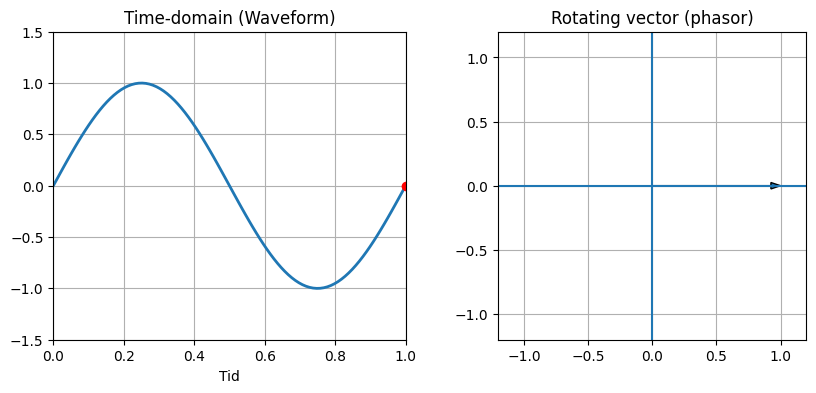

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
V = 1.0
omega = 2 * np.pi  # 1 Hz
theta = 0

# Time points
frames = 100
t_vals = np.linspace(0, 1, frames)

# Precompute full cosine
v_vals = V * np.sin(omega * t_vals + theta)

# Prepare figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left plot (waveform)
ax1.set_xlim(0, 1)
ax1.set_ylim(-1.5, 1.5)
ax1.set_title("Time-domain (Waveform)")
ax1.set_xlabel("Tid")
ax1.grid()

line, = ax1.plot([], [], lw=2)
point, = ax1.plot([], [], 'ro')

# Right plot (phasor)
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_aspect('equal')
ax2.set_title("Rotating vector (phasor)")
ax2.grid()

# Animation function
def animate(i):
    t = t_vals[i]
    angle = omega * t + theta

    # Phasor components
    x = V * np.cos(angle)
    y = V * np.sin(angle)

    # Redraw phasor axis cleanly
    ax2.clear()
    ax2.set_xlim(-1.2, 1.2)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_aspect('equal')
    ax2.set_title("Rotating vector (phasor)")
    ax2.grid()
    ax2.axhline(0)
    ax2.axvline(0)
    ax2.arrow(0, 0, x, y, head_width=0.05, length_includes_head=True)

    # Update waveform (NO append)
    line.set_data(t_vals[:i+1], v_vals[:i+1])
    point.set_data([t], [v_vals[i]])

    return line, point

# Use blitting for stability
ani = animation.FuncAnimation(
    fig, animate, frames=frames, interval=50, blit=True
)

# Display in notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

# Save GIF
ani.save("phasor_animation_sin.gif", writer='pillow', fps=20)

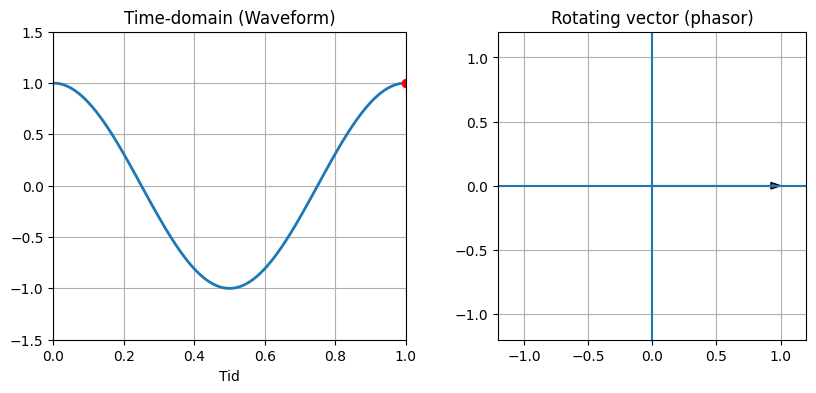

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
V = 1.0
omega = 2 * np.pi  # 1 Hz
theta = 0

# Time points
frames = 100
t_vals = np.linspace(0, 1, frames)

# Precompute full cosine
v_vals = V * np.cos(omega * t_vals + theta)

# Prepare figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left plot (waveform)
ax1.set_xlim(0, 1)
ax1.set_ylim(-1.5, 1.5)
ax1.set_title("Time-domain (Waveform)")
ax1.set_xlabel("Tid")
ax1.grid()

line, = ax1.plot([], [], lw=2)
point, = ax1.plot([], [], 'ro')

# Right plot (phasor)
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_aspect('equal')
ax2.set_title("Rotating vector (phasor)")
ax2.grid()

# Animation function
def animate(i):
    t = t_vals[i]
    angle = omega * t + theta

    # Phasor components
    x = V * np.cos(angle)
    y = V * np.sin(angle)

    # Redraw phasor axis cleanly
    ax2.clear()
    ax2.set_xlim(-1.2, 1.2)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_aspect('equal')
    ax2.set_title("Rotating vector (phasor)")
    ax2.grid()
    ax2.axhline(0)
    ax2.axvline(0)
    ax2.arrow(0, 0, x, y, head_width=0.05, length_includes_head=True)

    # Update waveform (NO append)
    line.set_data(t_vals[:i+1], v_vals[:i+1])
    point.set_data([t], [v_vals[i]])

    return line, point

# Use blitting for stability
ani = animation.FuncAnimation(
    fig, animate, frames=frames, interval=50, blit=True
)

# Display in notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

# Save GIF
ani.save("phasor_animation_fixed.gif", writer='pillow', fps=20)

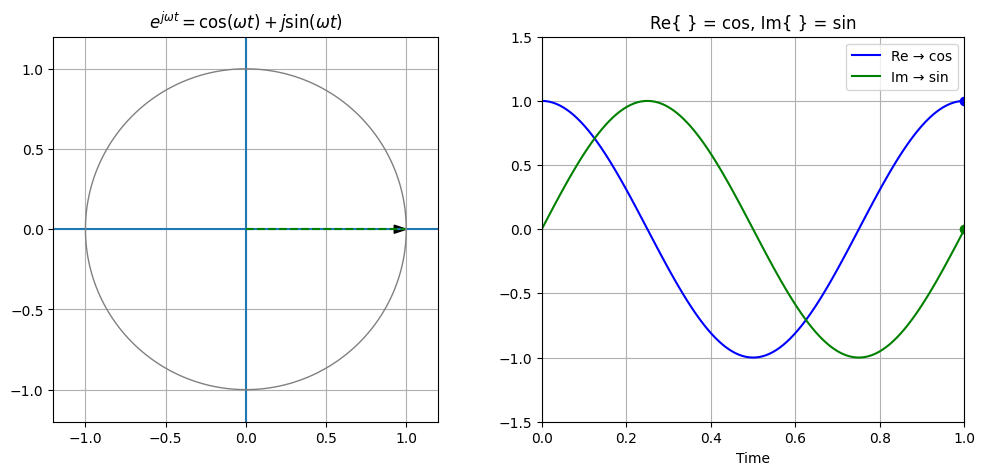

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parametere
V = 1.0
omega = 2 * np.pi
theta = 0

frames = 120
t_vals = np.linspace(0, 1, frames)

# Kompleks eksponential
z_vals = V * np.exp(1j * (omega * t_vals + theta))

# Re og Im
cos_vals = np.real(z_vals)
sin_vals = np.imag(z_vals)

# Figur
fig, (ax_complex, ax_time) = plt.subplots(1, 2, figsize=(12, 5))

# --- KOMPLEKSPLAN ---
ax_complex.set_xlim(-1.2, 1.2)
ax_complex.set_ylim(-1.2, 1.2)
ax_complex.set_aspect('equal')
ax_complex.set_title("Complex plane: $e^{j\\omega t}$")
ax_complex.grid()

# --- TIDSPLOTT ---
ax_time.set_xlim(0, 1)
ax_time.set_ylim(-1.5, 1.5)
ax_time.set_title("Re{ } = cos, Im{ } = sin")
ax_time.set_xlabel("Time")
ax_time.grid()

line_cos, = ax_time.plot([], [], label="Re → cos", color='blue')
line_sin, = ax_time.plot([], [], label="Im → sin", color='green')

point_cos, = ax_time.plot([], [], 'bo')
point_sin, = ax_time.plot([], [], 'go')

ax_time.legend()

def animate(i):
    t = t_vals[i]
    z = z_vals[i]

    x = np.real(z)
    y = np.imag(z)

    # --- KOMPLEKSPLAN ---
    ax_complex.clear()
    ax_complex.set_xlim(-1.2, 1.2)
    ax_complex.set_ylim(-1.2, 1.2)
    ax_complex.set_aspect('equal')
    ax_complex.set_title(r"$e^{j\omega t} = \cos(\omega t) + j\sin(\omega t)$")
    ax_complex.grid()

    ax_complex.axhline(0)
    ax_complex.axvline(0)

    # Vektor = e^{jωt}
    ax_complex.arrow(0, 0, x, y,
                     head_width=0.05,
                     length_includes_head=True,
                     color='black')

    # Projeksjoner
    ax_complex.plot([x, x], [0, y], 'b--', label="Re")
    ax_complex.plot([0, x], [y, y], 'g--', label="Im")

    # Sirkel (unit circle)
    theta_circle = np.linspace(0, 2*np.pi, 200)
    ax_complex.plot(np.cos(theta_circle), np.sin(theta_circle), 'gray', lw=1)

    # --- TIDSPLOTT ---
    line_cos.set_data(t_vals[:i+1], cos_vals[:i+1])
    line_sin.set_data(t_vals[:i+1], sin_vals[:i+1])

    point_cos.set_data([t], [cos_vals[i]])
    point_sin.set_data([t], [sin_vals[i]])

    return line_cos, line_sin, point_cos, point_sin

ani = animation.FuncAnimation(
    fig, animate, frames=frames, interval=50, blit=True
)

from IPython.display import HTML
HTML(ani.to_jshtml())

ani.save("complex_exponential.gif", writer='pillow', fps=20)